# Learning FitzHugh–Nagumo dynamics with Gaussian Process prior on drift

This **deep-dive tutorial** walks through drift inference for a FitzHugh–Nagumo (FHN) SDE.

**Goal.** Given noisy observations of the state, recover the drift $f(x)$ by placing a **truncated basis expansion of a Matérn-kernel Gaussian Process** prior on it. Each output dimension gets an independent expansion; with $\beta \sim \mathcal{N}(0, I)$, this approximates a Matérn GP prior. We fit via **SVI with AutoDelta** (posterior MAP) and **NUTS** (initialised at MAP) for **observation_dim 2** (observe both $v$ and $w$). We compare log-likelihoods, drift fields (NUTS posterior mean ± std), basis coefficients, and filtered states.

**What is known.**
- Initial state distribution: $x_0 \sim \mathcal{N}(0, I)$.
- Observation operator $H$ (identity here, observing both states).
- Diffusion coefficient $\sigma_x$ and observation noise covariance $R$ (fixed).
- Truncated Matérn basis (eigenfunctions $\Phi$, spectral density $\mathsf{SPD}$).

**What is inferred.**
- Drift basis coefficients $\beta$ via MAP (SVI with AutoDelta) and full posterior (NUTS).

## FitzHugh–Nagumo Model

### State SDE

The state $x_t = (v_t, w_t)^\top \in \mathbb{R}^2$ evolves as an Itô SDE:

$$
dx_t = f(x_t)\,dt + \sigma_x\,dW_t,
$$

where $W_t$ is a standard 2-dimensional Brownian motion and the true drift is

$$
f(x) = \begin{pmatrix} v - \tfrac{1}{3}v^3 - w + I \\ a\,(v + b - c\,w) \end{pmatrix}.
$$

Parameters are fixed at $a = 0.08$, $b = 0.7$, $c = 0.8$, $I = 0.5$. The diffusion coefficient $\sigma_x = 0.01$ is treated as **known** in this tutorial.

### Observation process

Observations are collected at discrete times $t_1 < t_2 < \cdots < t_n$:

$$
y_k = H\,x_{t_k} + \varepsilon_k, \qquad \varepsilon_k \sim \mathcal{N}(0,\,R),
$$

where $H = I_2$ (both states observed) and $R$ is a known covariance matrix.

### Initial condition

$$
x_0 \sim \mathcal{N}(0, I_2).
$$

### Inferred quantities

We do **not** know the drift $f$. We place a **truncated basis expansion of a Matérn-kernel GP** prior on it: each output dimension $d$ gets an independent expansion

$$
f_d(x) = \sqrt{\alpha_d}\,\Phi(x)\,(\mathsf{SPD} \odot \beta_d),
$$

and we stack them so $f(x) = [f_0(x), f_1(x)]^\top$. Here $\Phi(x)$ are Laplacian eigenfunctions, $\mathsf{SPD}$ is the spectral density (diagonal), and $\beta \sim \mathcal{N}(0, I)$ gives a Matérn GP prior. The basis coefficients $\beta$ are inferred via MAP (SVI with AutoDelta) and optionally via NUTS for a full posterior.

In [1]:
import jax
import jax.numpy as jnp
import jax.random as jr
import numpyro
import numpyro.distributions as dist
from numpyro.contrib.hsgp.approximation import (
    eigenfunctions,
    diag_spectral_density_matern,
)
from numpyro.infer import SVI, Trace_ELBO, Predictive, MCMC, NUTS, init_to_value
from numpyro.infer.autoguide import AutoDelta

import dynestyx as dsx

from dynestyx import (
    DynamicalModel,
    ContinuousTimeStateEvolution,
    LinearGaussianObservation,
    Filter,
    SDESimulator,
)
from dynestyx.diagnostics.plotting_utils import plot_drift_field
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np

## True system

Define the true FitzHugh–Nagumo drift. We will later build the full DynamicalModel by piping in this drift and spreading shared arguments from a dict.

In [2]:
# FitzHugh–Nagumo parameters
_a, _b, _c, _I = 0.08, 0.7, 0.8, 0.5


def fitzhugh_nagumo_drift(x):
    v, w = x[0], x[1]
    dv = v - (1 / 3) * v**3 - w + _I
    dw = _a * (v + _b - _c * w)
    return jnp.array([dv, dw])


state_dim = 2

## Model configuration

Shared settings for the SDE simulator, observation schedule, and inference (SVI steps, NUTS warmup/samples).

In [3]:
initial_cov_scale = 1.0
emission_cov_scale = 0.01
diffusion_coeff = 0.01
obs_times = jnp.arange(0.0, 50.0, 0.1)
num_steps = 400 # 4000
nuts_warmup = 20 # 50
nuts_samples = 100 # 200

observation_dim = 2  # observation_dim=1 also works (observe only v)

# Setup: RNG keys
key = jr.PRNGKey(0)
key, k_data, k_svi, k_nuts, k_filter = jr.split(key, 5)

## Shared DynamicalModel kwargs 

Collect commonly used kwargs for DynamicalModel into a single dictionary for convenience. This includes state and observation dimensions, initial condition distribution, and the observation model. These shared arguments will be supplied to each DynamicalModel instantiation, ensuring consistency across experiments. Example: see `dynamics_kwargs` in the next code cell.



In [4]:
H_obs = jnp.eye(observation_dim, state_dim)
R_obs = emission_cov_scale * jnp.eye(observation_dim)

# DynamicalModel arguments that don't change across models
dynamics_kwargs = dict(
    state_dim=state_dim,
    observation_dim=observation_dim,
    initial_condition=dist.MultivariateNormal(
        loc=jnp.zeros(state_dim),
        covariance_matrix=initial_cov_scale * jnp.eye(state_dim),
    ),
    observation_model=LinearGaussianObservation(H=H_obs, R=R_obs),
)


def make_state_evolution(drift_fn):
    return ContinuousTimeStateEvolution(
        drift=drift_fn,
        diffusion_coefficient=lambda x, u, t: diffusion_coeff * jnp.eye(state_dim),
    )

## Data generation

We simulate from the **true** FHN drift using an SDE simulator. The model observes the state at `obs_times` with Gaussian noise.

In [5]:
# True system: pipe in drift, **kwargs the rest
def model_with_true_drift(obs_times=None, obs_values=None):
    return dsx.sample(
        "f",
        DynamicalModel(
            state_evolution=make_state_evolution(
                lambda x, u, t: fitzhugh_nagumo_drift(x)
            ),
            **dynamics_kwargs,
        ),
        obs_times=obs_times,
        obs_values=obs_values,
    )

predictive = Predictive(
    model_with_true_drift, num_samples=1, exclude_deterministic=False
)
with SDESimulator():
    synthetic = predictive(k_data, obs_times=obs_times)

obs_values = synthetic["observations"][0]
states = synthetic["states"][0]
times_1d = jnp.asarray(obs_times).squeeze()

### Data visualization

Time series of the latent state and noisy observations, and the phase-space trajectory.

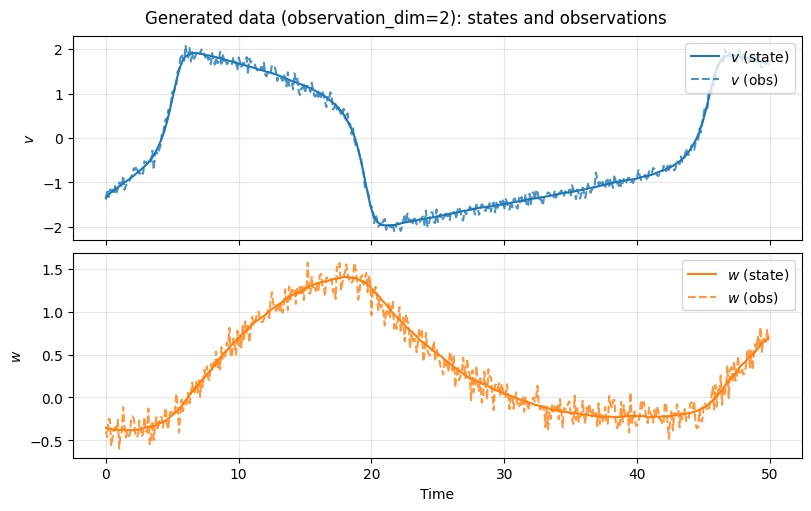

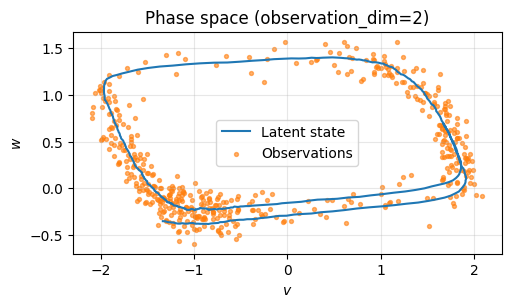

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(8, 5), sharex=True, constrained_layout=True)
axes[0].plot(times_1d, states[:, 0], label="$v$ (state)", color="C0")
axes[0].plot(
    times_1d, obs_values[:, 0], linestyle="--", alpha=0.8, label="$v$ (obs)", color="C0"
)
axes[0].set_ylabel("$v$")
axes[0].legend(loc="upper right")
axes[0].grid(True, alpha=0.3)
axes[1].plot(times_1d, states[:, 1], label="$w$ (state)", color="C1")
if observation_dim >= 2:
    axes[1].plot(
        times_1d,
        obs_values[:, 1],
        linestyle="--",
        alpha=0.8,
        label="$w$ (obs)",
        color="C1",
    )
axes[1].set_ylabel("$w$")
axes[1].set_xlabel("Time")
axes[1].legend(loc="upper right")
axes[1].grid(True, alpha=0.3)
fig.suptitle(
    f"Generated data (observation_dim={observation_dim}): states and observations"
)
plt.show()

fig, ax = plt.subplots(figsize=(5, 5), constrained_layout=True)
ax.plot(states[:, 0], states[:, 1], color="C0", label="Latent state", linewidth=1.5)
if observation_dim == 1:
    ax.scatter(
        obs_values[:, 0],
        jnp.zeros_like(obs_values[:, 0]),
        s=8,
        alpha=0.6,
        color="C1",
        label="Observations (v)",
    )
else:
    ax.scatter(
        obs_values[:, 0],
        obs_values[:, 1],
        s=8,
        alpha=0.6,
        color="C1",
        label="Observations",
    )
ax.set_xlabel("$v$")
ax.set_ylabel("$w$")
ax.set_title(f"Phase space (observation_dim={observation_dim})")
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_aspect("equal")
plt.show()

## Truncated Matérn basis: learning the drift with a GP prior

Now let's learn the drift from the observations. We use a **truncated basis expansion** of a Matérn-kernel GP: the drift $f: \mathbb{R}^2 \to \mathbb{R}^2$ is built by stacking independent expansions per output dimension. For dimension $d$, $f_d(x) = \sqrt{\alpha_d}\,\Phi(x) (\mathsf{SPD} \odot \beta_d)$ where $\Phi$ are Laplacian eigenfunctions, $\mathsf{SPD}$ is the spectral density (diagonal), and $\beta \sim \mathcal{N}(0, I)$. We define the eigenfunctions, spectral density, and `compute_drift(x, beta)`.

In [7]:
# Matérn truncated-basis hyperparameters
nu = 1.5  # smoothness parameter
length_scale = 1.0  # length scale of the Matérn kernel
ell_box = [4.0, 4.0]  # spatial domain of the GP
m = 10  # number of eigenfunctions
alpha = jnp.array([2.0**2, 0.2**2])  # scaling of the eigenfunctions

SPD = jnp.sqrt(
    diag_spectral_density_matern(
        nu=nu,
        alpha=1.0,
        length=length_scale,
        ell=ell_box,
        m=m,
        dim=state_dim,
    )
)
MSTAR = eigenfunctions(jnp.zeros((1, state_dim)), ell=ell_box, m=m).shape[-1]


def compute_drift(x, beta, spd=SPD, alpha_vec=alpha):
    x_ = jnp.atleast_2d(x)
    phi_x = eigenfunctions(x_, ell=ell_box, m=m)
    beta_scaled = beta * spd[:, None]
    out = phi_x @ beta_scaled
    out = out * jnp.sqrt(alpha_vec)
    return out[0] if x.ndim == 1 else out

## SVI with AutoDelta (MAP estimate)

We use stochastic variational inference with a **Delta** guide to find the posterior MAP of the basis coefficients $\beta$. The model is conditioned on observations via `FilterBasedMarginalLogLikelihood` (EnKF).

In [8]:
from dynestyx.inference.filter_configs import ContinuousTimeEnKFConfig

def model_with_gp_drift(obs_times=None, obs_values=None):
    beta = numpyro.sample(
        "beta", dist.Normal(0.0, 1.0).expand((MSTAR, state_dim)).to_event(2)
    )
    drift = lambda x, u, t: compute_drift(x, beta)
    return dsx.sample(
        "f",
        DynamicalModel(state_evolution=make_state_evolution(drift), **dynamics_kwargs),
        obs_times=obs_times,
        obs_values=obs_values,
    )

with Filter(
    ContinuousTimeEnKFConfig(
        n_particles=25,
        diffeqsolve_max_steps=200,
        diffeqsolve_dt0=0.01,
    )
):
    optimizer = numpyro.optim.Adam(step_size=1e-2)
    guide = AutoDelta(model_with_gp_drift)
    svi = SVI(model_with_gp_drift, guide, optimizer, loss=Trace_ELBO())
    svi_result = svi.run(k_svi, num_steps=num_steps, obs_times=obs_times, obs_values=obs_values)
    
beta_map = guide.median(svi_result.params)["beta"]

100%|██████████| 400/400 [07:32<00:00,  1.13s/it, init loss: 81311.5391, avg. loss [381-400]: -255.7539]


### SVI loss curve

The negative ELBO decreases as the MAP estimate is refined.

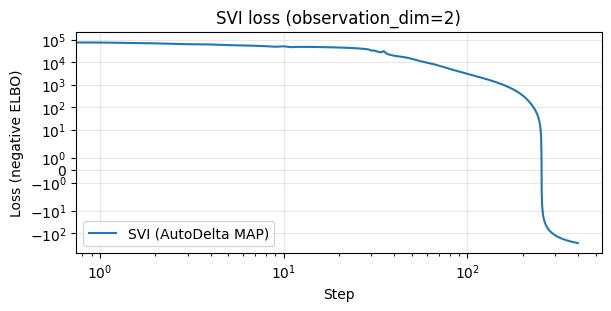

In [9]:
fig, ax = plt.subplots(figsize=(6, 3), constrained_layout=True)
ax.plot(svi_result.losses, color="C0", label="SVI (AutoDelta MAP)")
ax.set_yscale("symlog")
ax.set_xscale("log")
ax.set_xlabel("Step")
ax.set_ylabel("Loss (negative ELBO)")
ax.set_title(f"SVI loss (observation_dim={observation_dim})")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

## MAP drift field and log-likelihood

We use `Predictive` with the true and MAP drifts to get the marginal log-likelihood and filtered states via `FilterBasedMarginalLogLikelihood`. We compare the learned drift to the true drift.

log_lik: true=840.44  MAP drift=463.94


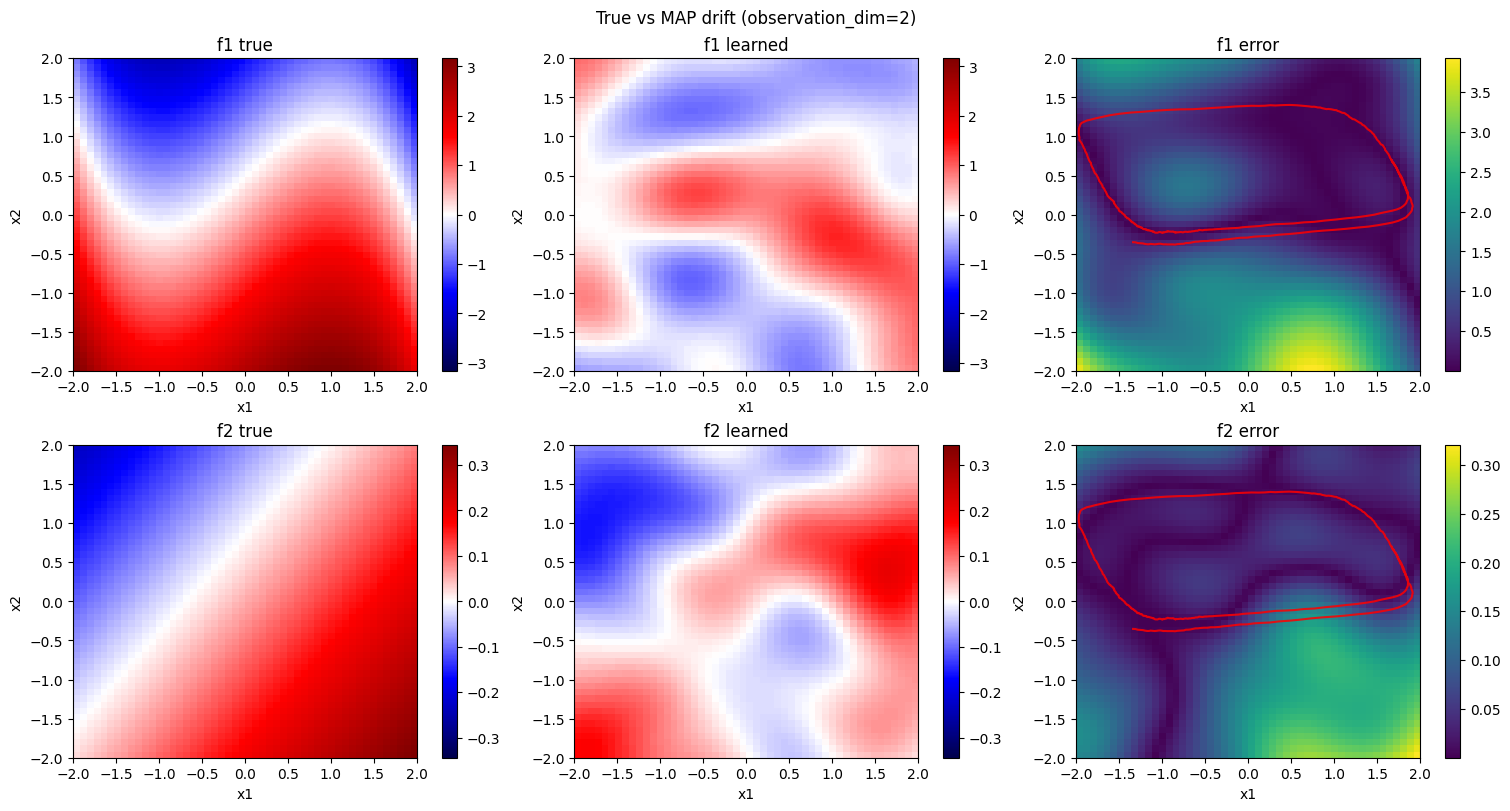

In [10]:
def make_dynamics(drift_fn):
    return DynamicalModel(
        state_evolution=make_state_evolution(drift_fn), **dynamics_kwargs
    )


with Filter(
    ContinuousTimeEnKFConfig(
        n_particles=25,
        diffeqsolve_max_steps=200,
        diffeqsolve_dt0=0.01,
    )
):
    predictive_true = Predictive(
        model_with_true_drift, num_samples=1, exclude_deterministic=False
    )
    pred_true = predictive_true(k_filter, obs_times=obs_times, obs_values=obs_values)
    log_lik_true = float(pred_true["f_marginal_loglik"][0])

    predictive_map = Predictive(
        model_with_gp_drift,
        guide=guide,
        params=svi_result.params,
        num_samples=1,
        exclude_deterministic=False,
    )
    pred_map = predictive_map(k_filter, obs_times=obs_times, obs_values=obs_values)
    log_lik_map = float(pred_map["f_marginal_loglik"][0])

print(f"log_lik: true={log_lik_true:.2f}  MAP drift={log_lik_map:.2f}")

x1_range = (-ell_box[0] / 2, ell_box[0] / 2)
x2_range = (-ell_box[1] / 2, ell_box[1] / 2)
kwargs_drift = dict(
    x1_range=x1_range,
    x2_range=x2_range,
    num_points=50,
    return_rmse=True,
    trajectory=jnp.asarray(states),
    trajectory_axes="error",
)
drift_map_fn = lambda x: compute_drift(x, beta_map)
fig_map, rmse_map = plot_drift_field(
    f_true=fitzhugh_nagumo_drift, f_learned=drift_map_fn, **kwargs_drift
)
fig_map.suptitle(f"True vs MAP drift (observation_dim={observation_dim})")
plt.show()

## NUTS MCMC

We run NUTS initialized at the MAP estimate to sample from the posterior over $\beta$. The posterior samples allow us to quantify uncertainty in the drift. The summary below reports mean, std, quantiles, and effective sample size (ESS); with one chain, R-hat is omitted.

In [ ]:
with Filter(
    ContinuousTimeEnKFConfig(
        n_particles=25,
        diffeqsolve_max_steps=200,
        diffeqsolve_dt0=0.01,
    )
):
    nuts_kernel = NUTS(
        model_with_gp_drift,
        init_strategy=init_to_value(values={"beta": beta_map}),
        max_tree_depth=6,
    )
    mcmc = MCMC(nuts_kernel, num_warmup=nuts_warmup, num_samples=nuts_samples, num_chains=1)
    mcmc.run(k_nuts, obs_times=obs_times, obs_values=obs_values)
beta_samples_nuts = mcmc.get_samples()["beta"]

print("NUTS summary (ESS, diagnostics):")
mcmc.print_summary()

sample:  28%|██▊       | 33/120 [53:54<5:11:16, 214.67s/it, 63 steps of size 2.94e-02. acc. prob=0.92]

## NUTS posterior: drift field and log-likelihood

We compute the **posterior mean and std of the drift** at each point by averaging over MCMC samples: $\bar{f}(x) = \frac{1}{M}\sum_i f(x; \beta_i)$. We then compare the NUTS-mean drift to the true drift and compute the marginal log-likelihood under the NUTS posterior mean.

log_lik: true drift=840.44  MAP drift=-19133.72  NUTS mean drift=-19133.71


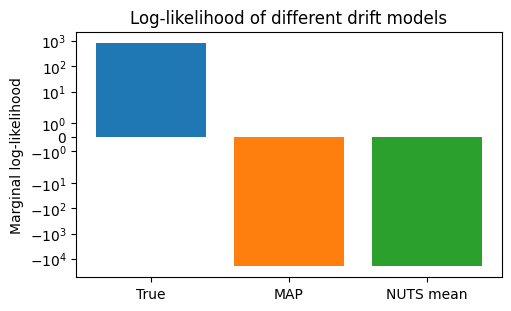

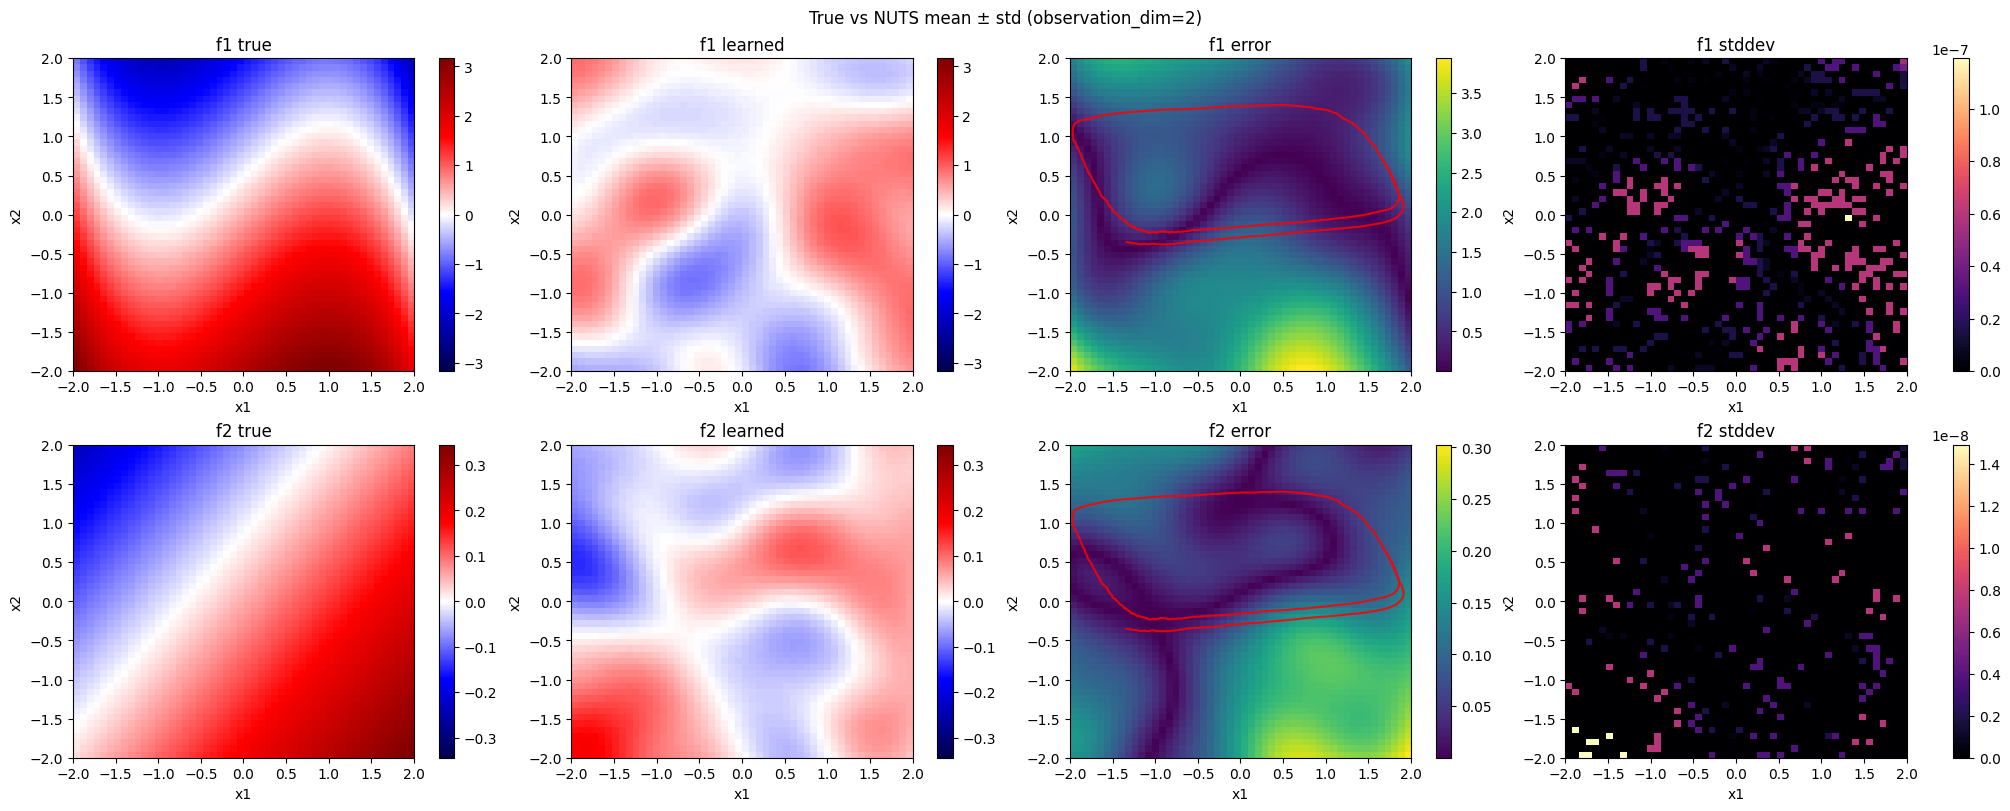

RMSE MAP vs true: 1.0128  NUTS mean vs true: 1.0128


In [ ]:
def f_nuts_loc_sd(x):
    vals = jax.vmap(lambda p: compute_drift(x, p))(beta_samples_nuts)
    return jnp.mean(vals, axis=0), jnp.std(vals, axis=0)


drift_nuts_mean = lambda x: f_nuts_loc_sd(x)[0]
drift_nuts_sd = lambda x: f_nuts_loc_sd(x)[1]
beta_nuts_mean = jnp.mean(beta_samples_nuts, axis=0)

# Log-lik of NUTS mean drift
with Filter(
    ContinuousTimeEnKFConfig(
        n_particles=25,
        diffeqsolve_max_steps=200,
        diffeqsolve_dt0=0.01,
    )
):
    predictive_nuts_mean = Predictive(
        model_with_gp_drift,
        posterior_samples={"beta": beta_nuts_mean[None, ...]},
        exclude_deterministic=False,
    )
    pred_nuts_mean = predictive_nuts_mean(k_filter, obs_times=obs_times, obs_values=obs_values)
    log_lik_nuts = float(pred_nuts_mean["f_marginal_loglik"][0])

    # Posterior predictive of filtered means (for CI in trajectory plot)
    predictive_nuts = Predictive(
        model_with_gp_drift,
        posterior_samples=mcmc.get_samples(),
        exclude_deterministic=False,
    )
    pred_nuts = predictive_nuts(k_filter, obs_times=obs_times, obs_values=obs_values)

print(
    f"log_lik: true drift={log_lik_true:.2f}  MAP drift={log_lik_map:.2f}  NUTS mean drift={log_lik_nuts:.2f}"
)

fig, ax = plt.subplots(figsize=(5, 3), constrained_layout=True)
ax.bar(
    ["True", "MAP", "NUTS mean"],
    [log_lik_true, log_lik_map, log_lik_nuts],
    color=["C0", "C1", "C2"],
)
ax.set_yscale("symlog")
ax.set_ylabel("Marginal log-likelihood")
ax.set_title(f"Log-likelihood of different drift models")
plt.show()

fig_nuts, rmse_nuts = plot_drift_field(
    f_true=fitzhugh_nagumo_drift,
    f_learned=drift_nuts_mean,
    f_learned_sd=drift_nuts_sd,
    **kwargs_drift,
)
fig_nuts.suptitle(f"True vs NUTS mean ± std (observation_dim={observation_dim})")
plt.show()
print(
    f"RMSE MAP vs true: {float(rmse_map):.4f}  NUTS mean vs true: {float(rmse_nuts):.4f}"
)

## Beta coefficients: MAP vs NUTS posterior

The learned drift uses the truncated expansion $f_d(x) = \sqrt{\alpha_d}\,\Phi(x)(\mathsf{SPD} \odot \beta_d)$ stacked over $d$. We compare MAP and NUTS posterior mean of $\beta$, and show marginal posteriors for the first few basis indices.

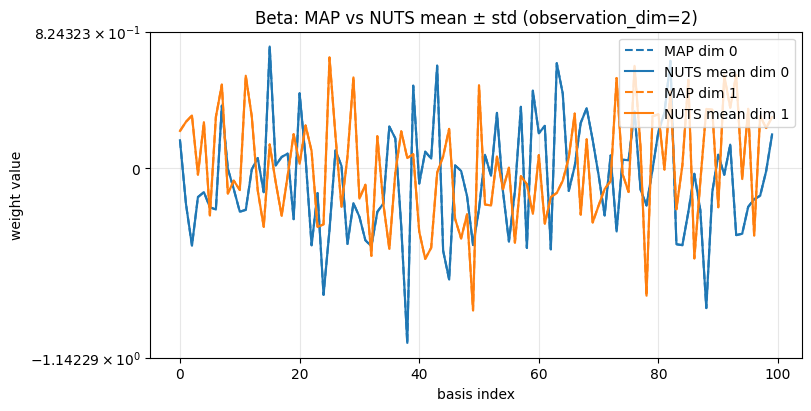

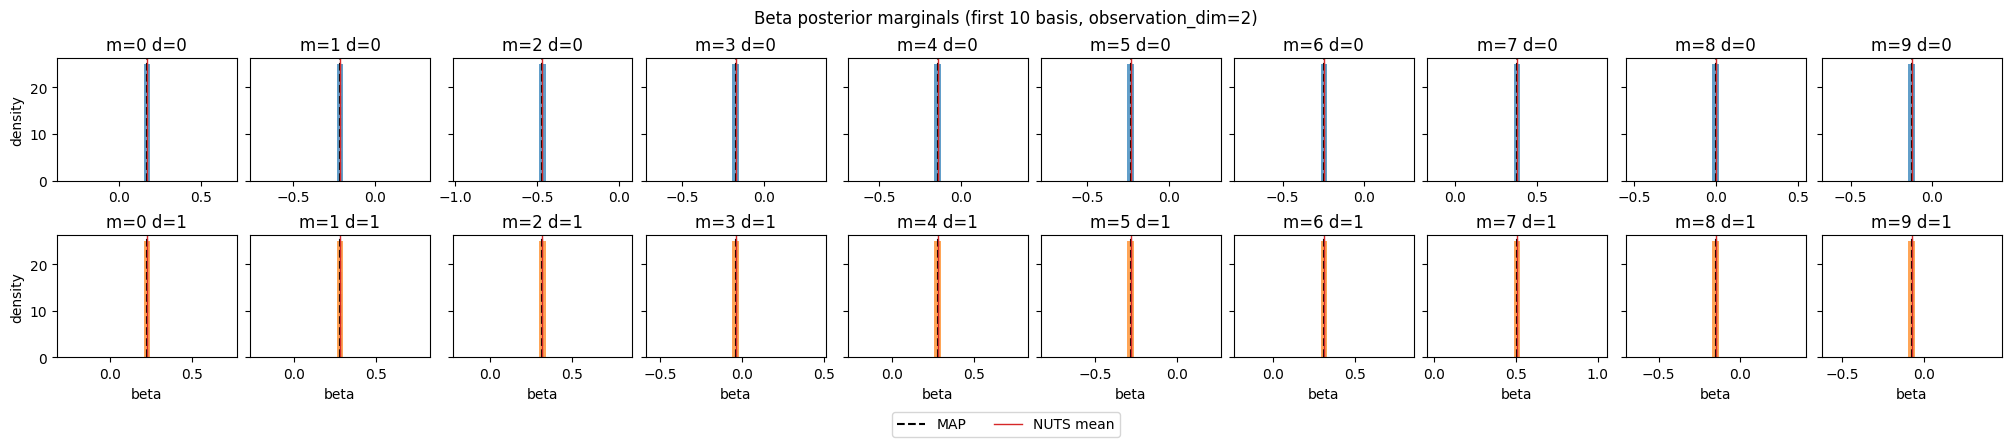

In [ ]:
beta_nuts_std = jnp.std(beta_samples_nuts, axis=0)
n_basis = beta_map.shape[0]
fig, ax = plt.subplots(figsize=(8, 4), constrained_layout=True)
for d in range(state_dim):
    ax.plot(
        np.arange(n_basis),
        np.asarray(beta_map[:, d]),
        linestyle="--",
        label=f"MAP dim {d}",
        color=f"C{d}",
    )
    ax.plot(
        np.arange(n_basis),
        np.asarray(beta_nuts_mean[:, d]),
        linestyle="-",
        label=f"NUTS mean dim {d}",
        color=f"C{d}",
    )
    sd_d = np.asarray(beta_nuts_std[:, d])
    ax.fill_between(
        np.arange(n_basis),
        np.asarray(beta_nuts_mean[:, d]) - sd_d,
        np.asarray(beta_nuts_mean[:, d]) + sd_d,
        alpha=0.2,
        color=f"C{d}",
    )
ax.set_xlabel("basis index")
ax.set_ylabel("weight value")
ax.set_title(f"Beta: MAP vs NUTS mean ± std (observation_dim={observation_dim})")
ax.legend(loc="upper right")
ax.set_yscale("symlog")
ax.grid(True, alpha=0.3)
plt.show()

n_show = min(10, n_basis)
fig, axes = plt.subplots(
    state_dim, n_show, figsize=(2 * n_show, 4), sharey="row", constrained_layout=True
)
if state_dim == 1:
    axes = axes[None, :]
for d in range(state_dim):
    for m in range(n_show):
        ax = axes[d, m]
        ax.hist(
            np.asarray(beta_samples_nuts[:, m, d]),
            bins=25,
            color=f"C{d}",
            alpha=0.7,
            density=True,
        )
        ax.axvline(float(beta_map[m, d]), color="k", linestyle="--", linewidth=1.5)
        ax.axvline(float(beta_nuts_mean[m, d]), color="C3", linestyle="-", linewidth=1)
        ax.set_title(f"m={m} d={d}")
        if m == 0:
            ax.set_ylabel("density")
        if d == state_dim - 1:
            ax.set_xlabel("beta")
fig.legend(
    [
        Line2D([0], [0], color="k", linestyle="--", linewidth=1.5),
        Line2D([0], [0], color="C3", linestyle="-", linewidth=1),
    ],
    ["MAP", "NUTS mean"],
    loc="upper center",
    bbox_to_anchor=(0.5, 0),
    ncol=2,
)
fig.suptitle(
    f"Beta posterior marginals (first {n_show} basis, observation_dim={observation_dim})"
)
plt.show()

## Filtered states

Filtered trajectories from Predictive (MAP and NUTS posterior) approximate the latent state given noisy observations. For NUTS we show the posterior predictive mean and 90% CI of filtered states.

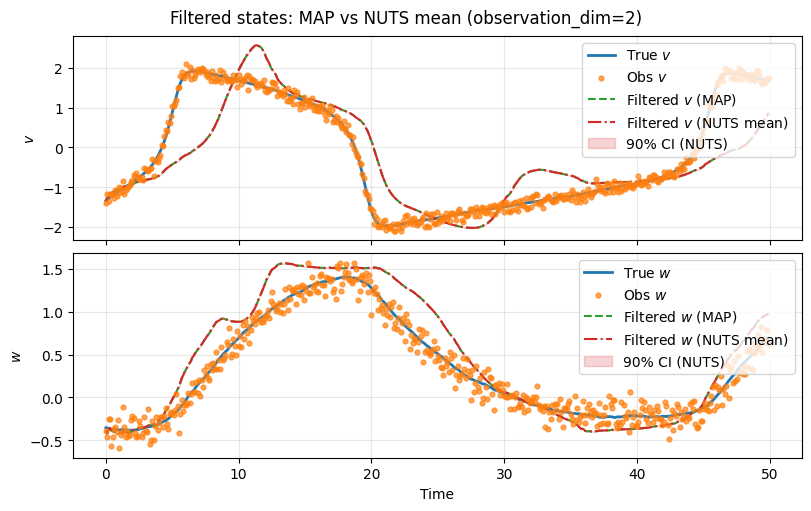

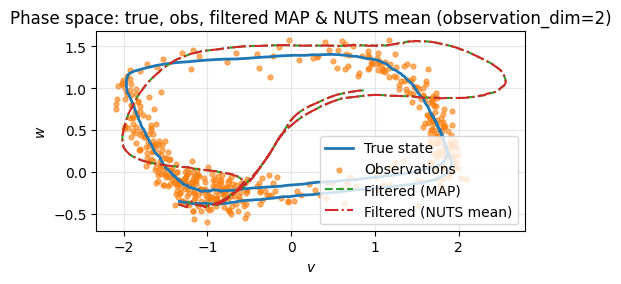

In [ ]:
filtered_means = np.asarray(pred_map["f_filtered_states_mean"][0])
filtered_means_nuts = np.asarray(pred_nuts["f_filtered_states_mean"]).mean(axis=0)
filtered_means_nuts_lo = np.percentile(pred_nuts["f_filtered_states_mean"], 5, axis=0)
filtered_means_nuts_hi = np.percentile(pred_nuts["f_filtered_states_mean"], 95, axis=0)
states_np = np.asarray(states)
obs_values_np = np.asarray(obs_values)
times_1d_np = np.asarray(times_1d)

fig, axes = plt.subplots(2, 1, figsize=(8, 5), sharex=True, constrained_layout=True)
axes[0].plot(times_1d_np, states_np[:, 0], label="True $v$", color="C0", linewidth=2)
axes[0].scatter(
    times_1d_np,
    obs_values_np[:, 0],
    s=12,
    alpha=0.7,
    color="C1",
    label="Obs $v$",
    zorder=3,
)
axes[0].plot(
    times_1d_np,
    filtered_means[:, 0],
    linestyle="--",
    label="Filtered $v$ (MAP)",
    color="C2",
)
axes[0].plot(
    times_1d_np,
    filtered_means_nuts[:, 0],
    linestyle="-.",
    label="Filtered $v$ (NUTS mean)",
    color="C3",
)
axes[0].fill_between(
    times_1d_np,
    filtered_means_nuts_lo[:, 0],
    filtered_means_nuts_hi[:, 0],
    alpha=0.2,
    color="C3",
    label="90% CI (NUTS)",
)
axes[0].set_ylabel("$v$")
axes[0].legend(loc="upper right")
axes[0].grid(True, alpha=0.3)
axes[1].plot(times_1d_np, states_np[:, 1], label="True $w$", color="C0", linewidth=2)
if observation_dim >= 2:
    axes[1].scatter(
        times_1d_np,
        obs_values_np[:, 1],
        s=12,
        alpha=0.7,
        color="C1",
        label="Obs $w$",
        zorder=3,
    )
axes[1].plot(
    times_1d_np,
    filtered_means[:, 1],
    linestyle="--",
    label="Filtered $w$ (MAP)",
    color="C2",
)
axes[1].plot(
    times_1d_np,
    filtered_means_nuts[:, 1],
    linestyle="-.",
    label="Filtered $w$ (NUTS mean)",
    color="C3",
)
axes[1].fill_between(
    times_1d_np,
    filtered_means_nuts_lo[:, 1],
    filtered_means_nuts_hi[:, 1],
    alpha=0.2,
    color="C3",
    label="90% CI (NUTS)",
)
axes[1].set_ylabel("$w$")
axes[1].set_xlabel("Time")
axes[1].legend(loc="upper right")
axes[1].grid(True, alpha=0.3)
fig.suptitle(f"Filtered states: MAP vs NUTS mean (observation_dim={observation_dim})")
plt.show()

fig, ax = plt.subplots(figsize=(5, 5), constrained_layout=True)
ax.plot(states_np[:, 0], states_np[:, 1], color="C0", label="True state", linewidth=2)
if observation_dim >= 2:
    ax.scatter(
        obs_values_np[:, 0],
        obs_values_np[:, 1],
        s=12,
        alpha=0.6,
        color="C1",
        label="Observations",
    )
else:
    ax.scatter(
        obs_values_np[:, 0],
        np.zeros_like(obs_values_np[:, 0]),
        s=12,
        alpha=0.6,
        color="C1",
        label="Observations (v)",
    )
ax.plot(
    filtered_means[:, 0],
    filtered_means[:, 1],
    linestyle="--",
    color="C2",
    label="Filtered (MAP)",
)
ax.plot(
    filtered_means_nuts[:, 0],
    filtered_means_nuts[:, 1],
    linestyle="-.",
    color="C3",
    label="Filtered (NUTS mean)",
)
ax.set_xlabel("$v$")
ax.set_ylabel("$w$")
ax.set_title(
    f"Phase space: true, obs, filtered MAP & NUTS mean (observation_dim={observation_dim})"
)
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_aspect("equal")
plt.show()

## Beta decay by magnitude

Posterior mean absolute values of $\beta$ coefficients, reordered by descending magnitude. Coefficients that shrink toward zero indicate basis functions that contribute little to the learned drift.

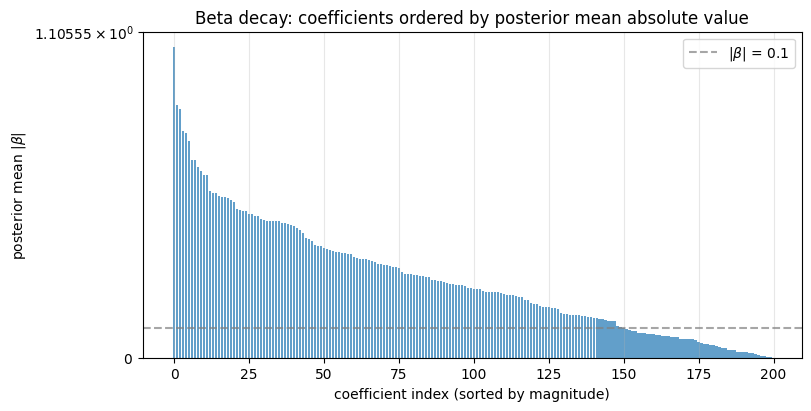

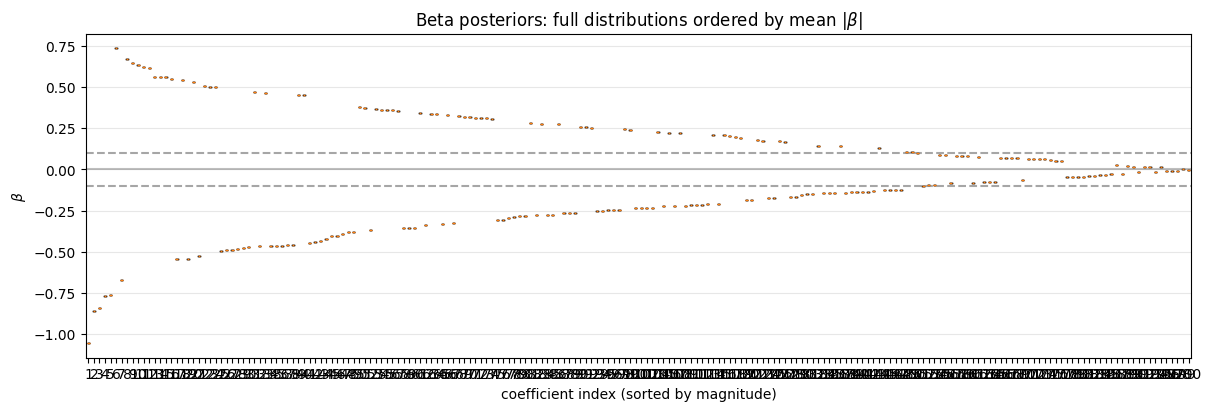

In [ ]:
# Posterior mean |beta| per coefficient (flatten m, d), sorted descending
beta_mean_abs = np.mean(np.abs(beta_samples_nuts), axis=0)  # (MSTAR, state_dim)
beta_flat = beta_mean_abs.ravel()
order = np.argsort(beta_flat)[::-1]
beta_sorted = beta_flat[order]

fig, ax = plt.subplots(figsize=(8, 4), constrained_layout=True)
ax.bar(
    np.arange(len(beta_sorted)), beta_sorted, color="C0", alpha=0.7, edgecolor="none"
)
ax.set_xlabel("coefficient index (sorted by magnitude)")
ax.set_ylabel("posterior mean |$\\beta$|")
ax.set_title("Beta decay: coefficients ordered by posterior mean absolute value")
ax.set_yscale("symlog")
ax.axhline(0.1, color="gray", linestyle="--", alpha=0.7, label="|$\\beta$| = 0.1")
ax.legend(loc="upper right")
ax.grid(True, alpha=0.3)
plt.show()

# Box plot: full posteriors in same order (coefficients ranked by mean |beta|)
beta_posterior_flat = np.asarray(beta_samples_nuts).reshape(
    beta_samples_nuts.shape[0], -1
)
beta_posterior_sorted = beta_posterior_flat[:, order]
fig, ax = plt.subplots(figsize=(12, 4), constrained_layout=True)
bp = ax.boxplot(
    [beta_posterior_sorted[:, j] for j in range(beta_posterior_sorted.shape[1])],
    patch_artist=True,
    showfliers=False,
)
for patch in bp["boxes"]:
    patch.set_facecolor("C0")
    patch.set_alpha(0.6)
ax.axhline(0, color="gray", linestyle="-", alpha=0.5)
ax.axhline(0.1, color="gray", linestyle="--", alpha=0.7)
ax.axhline(-0.1, color="gray", linestyle="--", alpha=0.7)
ax.set_xlabel("coefficient index (sorted by magnitude)")
ax.set_ylabel("$\\beta$")
ax.set_title("Beta posteriors: full distributions ordered by mean |$\\beta$|")
ax.grid(True, alpha=0.3, axis="y")
plt.show()